In [182]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [353]:
def jackson_kernel(moments):
    """
    Apply the Jackson kernel to Chebyshev moments.

    Parameters
    ----------
    moments : array-like
        1D array of Chebyshev moments mu_n, n = 0, ..., M-1.

    Returns
    -------
    np.ndarray
        Jackson-damped moments.
    """
    moments = np.asarray(moments, dtype=float)
    M = moments.size

    if M == 0:
        raise ValueError("moments must be non-empty")

    n = np.arange(M, dtype=float)
    alpha = np.pi / (M + 1)
    cot_alpha = 1.0 / np.tan(alpha)

    g = (
        (M - n + 1) * np.cos(alpha * n)
        + np.sin(alpha * n) * cot_alpha
    ) / (M + 1)

    return g * moments

def kpm_approx(moments, grid, jackson=True):
    theta = np.arccos(grid)                      # shape (Nx,)
    n = np.arange(len(moments))[:, None]      # shape (Nm, 1)

    T = np.cos(n * theta)                     # shape (Nm, Nx)

    if jackson:
        coeffs = jackson_kernel(moments)
    else:
        coeffs = moments.copy()

    coeffs[1:] *= 2.0

    f = np.sum(coeffs[:, None] * T, axis=0)
    f /= (np.pi * np.sqrt(1.0 - grid**2))

    return f

In [354]:
E = np.linspace(-0.99, 0.99, 400)
D = kpm_approx(np.asarray(pd.read_csv("data/dos-256x256-3_L-yopen.txt")["mu"]), E)

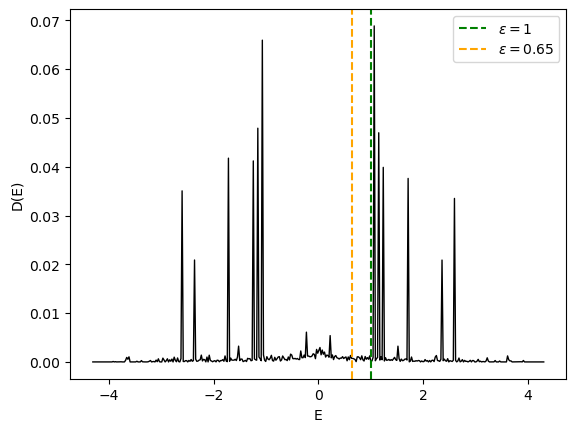

In [355]:
plt.plot(E / 0.23, D * 0.23, linewidth=1, color="black")
plt.xlabel("E")
plt.ylabel("D(E)")
plt.axvline(1, linestyle="dashed", color="green", label=r"$\varepsilon=1$")
plt.axvline(0.65, linestyle="dashed", color="orange", label=r"$\varepsilon=0.65$")
plt.legend()

Text(0.5, 1.0, '$\\varepsilon=0.65$')

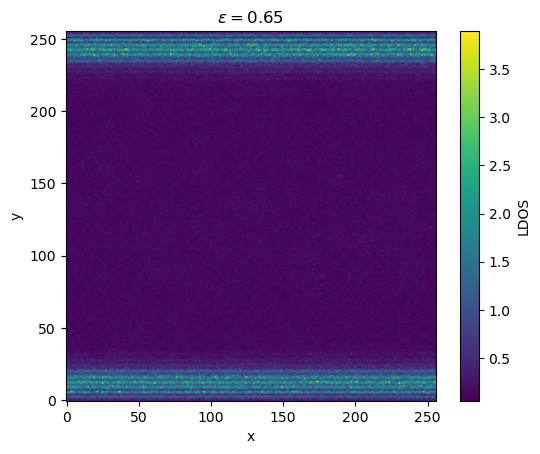

In [323]:
ldos = pd.read_csv("data/ldos-0.650000-256x256-21_L-yopen.txt")["ldos"]
ldos = np.array(ldos).reshape((256, 256))
plt.imshow(ldos, origin="lower")
plt.colorbar(label="LDOS")
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"$\varepsilon=0.65$")

Text(0.5, 1.0, '$\\varepsilon=1.0$')

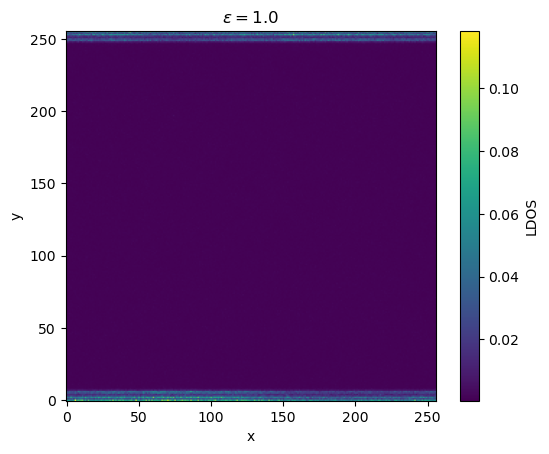

In [318]:
ldos = pd.read_csv("data/ldos-1.000000-256x256-21_L-yopen.txt")["ldos"]
ldos = np.array(ldos).reshape((256, 256))
plt.imshow(ldos, origin="lower")
plt.colorbar(label="LDOS")
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"$\varepsilon=1.0$")

0.20040510527375774
0.04106355819934859
0.5868364978038102
0.10487262057866843


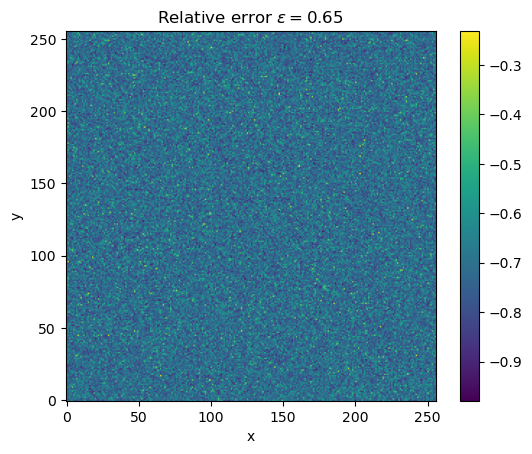

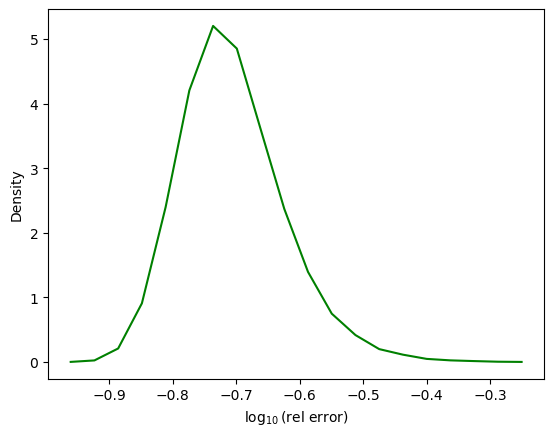

In [327]:
data = pd.read_csv("data/ldos-0.650000-256x256-21_L-yopen.txt")
ldos = np.array(data["ldos"]).reshape((256, 256))
var = np.array(data["variance"]).reshape((256, 256))
rel_error = np.sqrt(var) / ldos
print(np.mean(rel_error))
print(np.std(rel_error))
print(np.max(rel_error))
print(np.min(rel_error))
plt.imshow(np.log10(rel_error), origin="lower")
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"Relative error $\varepsilon=0.65$")
plt.show()

counts, edges = np.histogram(np.log10(np.asarray(rel_error).ravel()), bins=20, density=True)
centers = 0.5 * (edges[:-1] + edges[1:])

plt.plot(centers, counts, color="green")
plt.xlabel(r"$\log_{10}(\mathrm{rel\ error})$")
plt.ylabel("Density")
plt.show()

0.20403418913268645
0.04313040444605237
0.6935537956970391
0.10815561459135686


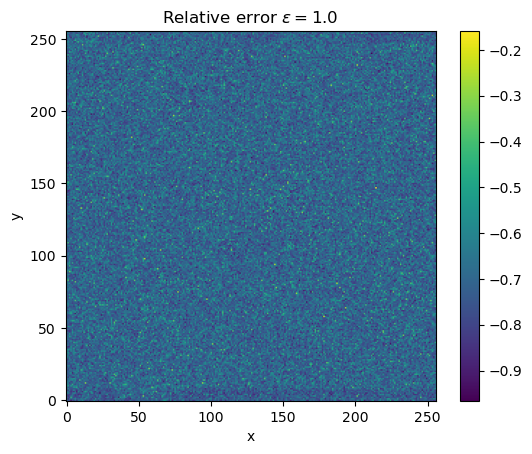

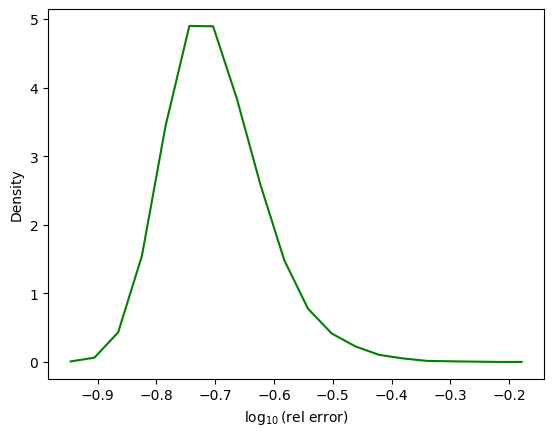

In [332]:
data = pd.read_csv("data/ldos-1.000000-256x256-21_L-yopen.txt")
ldos = np.array(data["ldos"]).reshape((256, 256))
var = np.array(data["variance"]).reshape((256, 256))
rel_error = np.sqrt(var) / ldos
print(np.mean(rel_error))
print(np.std(rel_error))
print(np.max(rel_error))
print(np.min(rel_error))
plt.imshow(np.log10(rel_error), origin="lower")
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"Relative error $\varepsilon=1.0$")
plt.show()

counts, edges = np.histogram(np.log10(np.asarray(rel_error).ravel()), bins=20, density=True)
centers = 0.5 * (edges[:-1] + edges[1:])

plt.plot(centers, counts, color="green")
plt.xlabel(r"$\log_{10}(\mathrm{rel\ error})$")
plt.ylabel("Density")
plt.show()